# Large Language Models (LLMs)

**CSCI 394 -- Spring 2026 Tutorial**

In this tutorial, you will explore Large Language Models (LLMs) hands-on:

## What you will learn

1. What a language model is and how tokenization works
2. The Transformer architecture and self-attention mechanism
3. How to load and run a pre-trained LLM with Hugging Face
4. How to measure generation throughput
5. Prompt engineering techniques
6. How LLMs connect to the HPC topics we have studied

## Background

A **language model** predicts the probability of the next token given preceding tokens.
A **large** language model (LLM) is a language model with billions of parameters,
trained on trillions of tokens from books, websites, code, and other sources.

| Year | Model | Key idea |
| ---- | ----- | -------- |
| 2017 | Transformer | Self-attention replaces recurrence |
| 2018 | GPT-1 (117M) | Decoder-only, pre-train then fine-tune |
| 2018 | BERT (340M) | Encoder-only, masked language modeling |
| 2020 | GPT-3 (175B) | In-context learning, few-shot prompting |
| 2022 | ChatGPT | RLHF -- aligning models to follow instructions |
| 2023-25 | Llama, Claude, Gemini | Open-weight, multimodal, reasoning |

## Step 0: Setup

We need `transformers` (Hugging Face) and `torch`.

**On Google Colab:** Go to `Runtime > Change runtime type > GPU` for faster inference.

**On Polaris:** `module load conda && conda activate` provides everything.

In [5]:
# Install dependencies (uncomment if needed)
# !pip install torch transformers matplotlib

import torch
import time
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch version: {torch.__version__}")

# Select device
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch, "xpu") and torch.xpu.is_available():
    device = torch.device("xpu")
    print(f"Using XPU: {torch.xpu.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device: {device}")

PyTorch version: 2.10.0
Using Apple MPS
Device: mps


---

## Part 1: Tokenization

LLMs do not see raw text. Text is first split into **tokens** -- sub-word
units -- each mapped to an integer ID. The model's vocabulary is a fixed
set of these tokens (typically 32K--128K entries).

Common tokenization algorithms:
- **Byte-Pair Encoding (BPE)**: used by GPT, Llama
- **WordPiece**: used by BERT
- **SentencePiece / Unigram**: used by T5

### Why sub-words?

- Word-level: vocabulary too large, can't handle new words
- Character-level: sequences too long, hard to learn meaning
- Sub-word: balances vocabulary size with sequence length

In [1]:
from transformers import AutoTokenizer

# Load the GPT-2 tokenizer (small, no auth required)
tokenizer = AutoTokenizer.from_pretrained("gpt2")

# Tokenize some example sentences
examples = [
    "Hello, world!",
    "Supercomputing enables breakthroughs in science.",
    "The Transformer architecture uses self-attention.",
    "MPI_Send transmits a buffer to a destination rank.",
    "asdfjkl;",  # nonsense -- watch how tokens differ
]

print(f"Vocabulary size: {tokenizer.vocab_size:,}\n")

for text in examples:
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.encode(text)
    print(f"Text:     {text}")
    print(f"Tokens:   {tokens}")
    print(f"IDs:      {ids}")
    print(f"# tokens: {len(tokens)}")
    print()

Vocabulary size: 50,257

Text:     Hello, world!
Tokens:   ['Hello', ',', 'Ġworld', '!']
IDs:      [15496, 11, 995, 0]
# tokens: 4

Text:     Supercomputing enables breakthroughs in science.
Tokens:   ['Super', 'com', 'puting', 'Ġenables', 'Ġbreakthrough', 's', 'Ġin', 'Ġscience', '.']
IDs:      [12442, 785, 48074, 13536, 19304, 82, 287, 3783, 13]
# tokens: 9

Text:     The Transformer architecture uses self-attention.
Tokens:   ['The', 'ĠTrans', 'former', 'Ġarchitecture', 'Ġuses', 'Ġself', '-', 'att', 'ention', '.']
IDs:      [464, 3602, 16354, 10959, 3544, 2116, 12, 1078, 1463, 13]
# tokens: 10

Text:     MPI_Send transmits a buffer to a destination rank.
Tokens:   ['MP', 'I', '_', 'Send', 'Ġtransm', 'its', 'Ġa', 'Ġbuffer', 'Ġto', 'Ġa', 'Ġdestination', 'Ġrank', '.']
IDs:      [7378, 40, 62, 25206, 21595, 896, 257, 11876, 284, 257, 10965, 4279, 13]
# tokens: 13

Text:     asdfjkl;
Tokens:   ['as', 'df', 'j', 'kl', ';']
IDs:      [292, 7568, 73, 41582, 26]
# tokens: 5



### Exercise 1a: Tokenization exploration

Try tokenizing the following and observe the differences:
1. A sentence in a language other than English
2. A Python code snippet (`def hello(): print('hi')`)
3. A very long word vs. a common short word
4. Numbers: `42` vs `42000` vs `3.14159`

In [4]:
# YOUR CODE HERE -- try your own sentences
my_text = "def hello(): print('hi')"
tokens = tokenizer.tokenize(my_text)
print(f"Text:   {my_text}")
print(f"Tokens: {tokens}")
print(f"Count:  {len(tokens)}")

Text:   def hello(): print('hi')
Tokens: ['def', 'Ġhello', '():', 'Ġprint', "('", 'hi', "')"]
Count:  7


### Visualize token lengths across text types

Let's see how the number of tokens varies for different kinds of input.

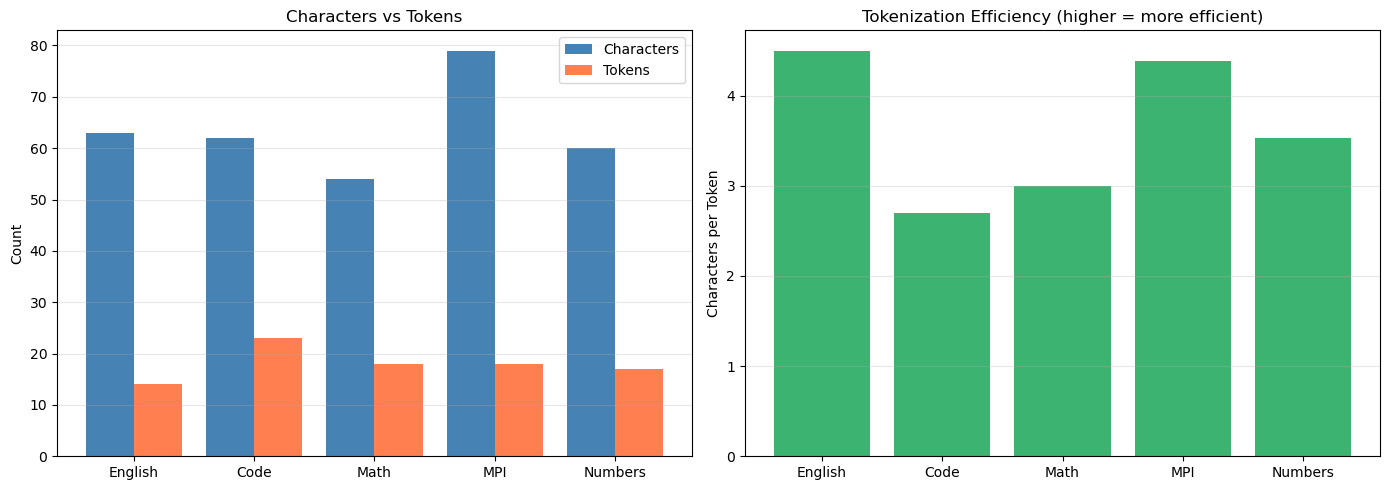

In [7]:
samples = {
    "English": "The quick brown fox jumps over the lazy dog near the riverbank.",
    "Code": "for i in range(10):\n    result += compute(data[i], weights[i])",
    "Math": "E = mc^2, where m is mass and c is the speed of light.",
    "MPI": "MPI_Allreduce performs a global reduction across all ranks in the communicator.",
    "Numbers": "The lattice has dimensions 128x128x128 with 3.14159 spacing.",
}

labels = list(samples.keys())
char_counts = [len(s) for s in samples.values()]
token_counts = [len(tokenizer.tokenize(s)) for s in samples.values()]
ratios = [c / t for c, t in zip(char_counts, token_counts)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(labels))
ax1.bar(x - 0.2, char_counts, 0.4, label="Characters", color="steelblue")
ax1.bar(x + 0.2, token_counts, 0.4, label="Tokens", color="coral")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel("Count")
ax1.set_title("Characters vs Tokens")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

ax2.bar(labels, ratios, color="mediumseagreen")
ax2.set_ylabel("Characters per Token")
ax2.set_title("Tokenization Efficiency (higher = more efficient)")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

---

## Part 2: The Transformer Architecture

The Transformer (Vaswani et al., 2017) is the architecture behind all modern LLMs.

### Key components

Each Transformer layer contains:
1. **Multi-Head Self-Attention** -- each token attends to all other tokens
2. **Feed-Forward Network (FFN)** -- a position-wise MLP
3. **Layer Normalization + Residual Connections** -- stabilize training

### Self-Attention

Given input **X**, we project into Query (**Q**), Key (**K**), and Value (**V**):

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

The $\sqrt{d_k}$ scaling prevents dot products from growing too large.

Let's implement self-attention from scratch to build intuition.

In [8]:
import torch
import torch.nn.functional as F

def self_attention(X, W_Q, W_K, W_V):
    """
    Compute single-head self-attention.
    
    Args:
        X: input embeddings, shape (seq_len, d_model)
        W_Q, W_K, W_V: projection matrices, shape (d_model, d_k)
    
    Returns:
        output: attended values, shape (seq_len, d_k)
        attention_weights: shape (seq_len, seq_len)
    """
    Q = X @ W_Q  # (seq_len, d_k)
    K = X @ W_K  # (seq_len, d_k)
    V = X @ W_V  # (seq_len, d_k)
    
    d_k = Q.shape[-1]
    scores = Q @ K.T / (d_k ** 0.5)  # (seq_len, seq_len)
    weights = F.softmax(scores, dim=-1)
    output = weights @ V  # (seq_len, d_k)
    
    return output, weights


# Demo: 4-token sentence with d_model=8, d_k=4
torch.manual_seed(42)

seq_len, d_model, d_k = 4, 8, 4
tokens = ["The", "cat", "sat", "down"]

X = torch.randn(seq_len, d_model)  # pretend embeddings
W_Q = torch.randn(d_model, d_k)
W_K = torch.randn(d_model, d_k)
W_V = torch.randn(d_model, d_k)

output, attn_weights = self_attention(X, W_Q, W_K, W_V)

print("Attention weights (each row sums to 1):")
print(f"  Rows = query token, Columns = key token\n")
for i, tok in enumerate(tokens):
    row = "  ".join(f"{w:.3f}" for w in attn_weights[i])
    print(f"  {tok:>5s} -> [{row}]")
print(f"\nOutput shape: {output.shape}")

Attention weights (each row sums to 1):
  Rows = query token, Columns = key token

    The -> [0.000  0.003  0.997  0.000]
    cat -> [0.519  0.000  0.480  0.001]
    sat -> [0.018  0.980  0.000  0.002]
   down -> [0.001  0.996  0.000  0.003]

Output shape: torch.Size([4, 4])


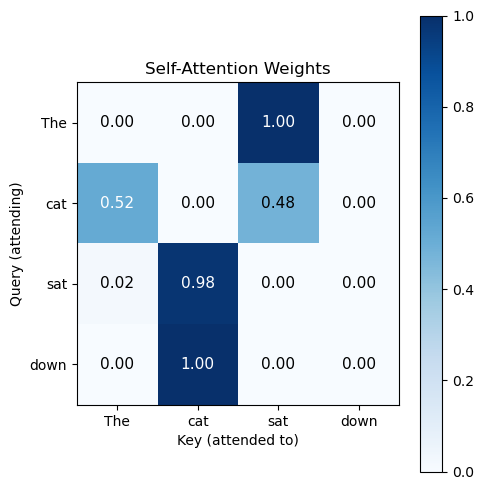

In [9]:
# Visualize the attention weights as a heatmap
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(attn_weights.detach().numpy(), cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
ax.set_xticklabels(tokens)
ax.set_yticklabels(tokens)
ax.set_xlabel("Key (attended to)")
ax.set_ylabel("Query (attending)")
ax.set_title("Self-Attention Weights")

for i in range(seq_len):
    for j in range(seq_len):
        val = attn_weights[i, j].item()
        color = "white" if val > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=11)

plt.colorbar(im)
plt.tight_layout()
plt.show()

### Causal (decoder-only) masking

In a decoder-only LLM (GPT, Llama, Claude), each token can only attend to
tokens **before** it (and itself). This is enforced with a **causal mask**
that sets future positions to $-\infty$ before the softmax.

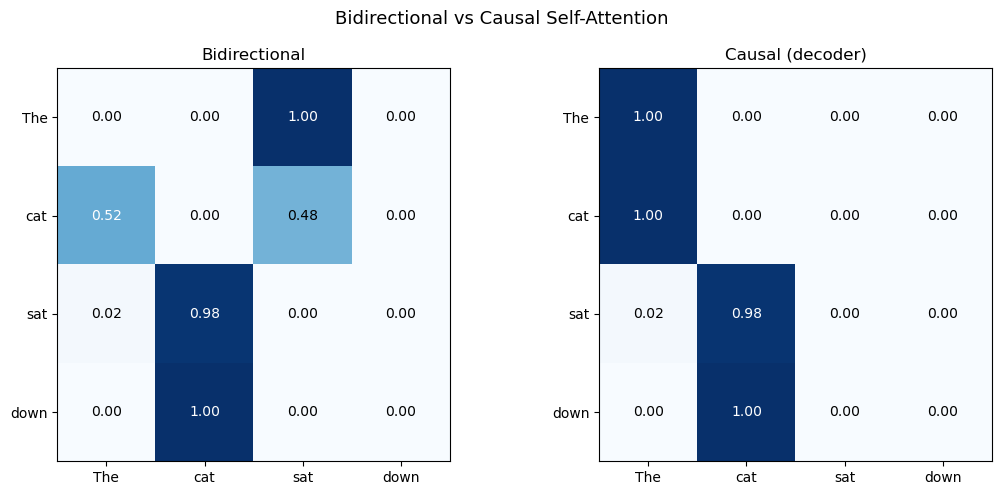

Notice: in the causal version, each token can only attend to itself and earlier tokens.
The upper-right triangle is zeroed out.


In [10]:
def causal_self_attention(X, W_Q, W_K, W_V):
    """Self-attention with causal (autoregressive) mask."""
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V
    
    d_k = Q.shape[-1]
    scores = Q @ K.T / (d_k ** 0.5)
    
    # Apply causal mask: set future positions to -inf
    seq_len = scores.shape[0]
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
    scores = scores.masked_fill(mask, float("-inf"))
    
    weights = F.softmax(scores, dim=-1)
    output = weights @ V
    return output, weights


output_causal, attn_causal = causal_self_attention(X, W_Q, W_K, W_V)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

for ax, w, title in [(ax1, attn_weights, "Bidirectional"), (ax2, attn_causal, "Causal (decoder)")]:
    im = ax.imshow(w.detach().numpy(), cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(tokens)
    ax.set_yticklabels(tokens)
    ax.set_title(title)
    for i in range(seq_len):
        for j in range(seq_len):
            val = w[i, j].item()
            color = "white" if val > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=10)

plt.suptitle("Bidirectional vs Causal Self-Attention", fontsize=13)
plt.tight_layout()
plt.show()

print("Notice: in the causal version, each token can only attend to itself and earlier tokens.")
print("The upper-right triangle is zeroed out.")

---

## Part 3: Loading and Running a Pre-trained LLM

We will use **GPT-2** (124M parameters) from Hugging Face. It's small
enough to run on any hardware (even CPU) and doesn't require authentication.

### How autoregressive generation works

1. **Prefill**: feed the prompt through the model
2. **Decode**: sample or greedily pick the next token
3. Append the token to the context and repeat

In [11]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "gpt2"

print(f"Loading {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

num_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded: {num_params/1e6:.1f}M parameters on {device}")

Loading gpt2...
Model loaded: 124.4M parameters on mps


In [14]:
# Generate text from a prompt
prompt = "The future of supercomputing is"

inputs = tokenizer(prompt, return_tensors="pt").to(device)
print(f"Prompt: '{prompt}'")
print(f"Prompt tokens: {inputs['input_ids'].shape[1]}\n")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.8,
        top_p=0.9,
    )

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("Generated text:")
print("-" * 60)
print(generated_text)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: 'The future of supercomputing is'
Prompt tokens: 7

Generated text:
------------------------------------------------------------
The future of supercomputing is one of growing interest in new and innovative ways to harness its power.

This year, IBM and Intel announced a partnership to jointly develop an "Efficient Computing Machine" that will use IBM's Deep Learning, a machine that uses a computer's natural language processing to compute complex mathematical operations.

These breakthroughs in artificial intelligence are in line with the goals of Microsoft's Azure cloud services. Microsoft has said that it plans to launch a cloud service with IBM's Deep Learning, which is a


### Decoding strategies

The model outputs a probability distribution over the vocabulary at each step.
How we pick the next token affects the output quality:

| Strategy | Description |
| -------- | ----------- |
| **Greedy** | Always pick the highest-probability token |
| **Top-k** | Sample from the top k most probable tokens |
| **Top-p (nucleus)** | Sample from the smallest set with cumulative prob >= p |
| **Temperature** | Scale logits by 1/T (T<1 = sharper, T>1 = more random) |

In [15]:
# Compare decoding strategies on the same prompt
prompt = "Parallel computing is important because"
inputs = tokenizer(prompt, return_tensors="pt").to(device)

strategies = {
    "Greedy": dict(do_sample=False),
    "Top-k (k=50)": dict(do_sample=True, top_k=50, temperature=1.0),
    "Top-p (p=0.9)": dict(do_sample=True, top_p=0.9, temperature=1.0),
    "High temp (T=1.5)": dict(do_sample=True, temperature=1.5),
    "Low temp (T=0.3)": dict(do_sample=True, temperature=0.3),
}

print(f"Prompt: '{prompt}'\n")

for name, kwargs in strategies.items():
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=40, **kwargs)
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    # Show only the generated part
    generated = text[len(prompt):]
    print(f"[{name}]")
    print(f"  ...{generated.strip()}")
    print()

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: 'Parallel computing is important because'



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[Greedy]
  ...it allows us to perform computations on a large number of parallel processors.

The main problem with parallel computing is that it is not scalable. It is not scalable because it is not scalable because



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[Top-k (k=50)]
  ...it can generate a lot of very useful knowledge about the physical world."

The next step in the study, he said, will be finding an algorithm that can be used for studying the physical world



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[Top-p (p=0.9)]
  ...it allows the user to access the database faster than using regular SQL databases (like a database of data) and, in some scenarios, makes it possible for users to access the database more rapidly.



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[High temp (T=1.5)]
  ...each algorithm could execute across multiple processors. In contrast, a virtual machine is limited by the complexity associated with moving multiple components across the CPU (by a variety of rules, including:

CPU-

[Low temp (T=0.3)]
  ...it allows us to easily create new data structures and perform computations in parallel.

In the past, we've used a number of different parallel computing techniques to create data structures. In this article



---

## Part 4: Measuring Generation Throughput

For HPC applications, we care about **tokens per second** -- how fast the
model can generate text. This depends on:
- Model size (parameters)
- Hardware (GPU type, memory bandwidth)
- Batch size
- Precision (FP32 vs FP16/BF16)
- Sequence length (longer = slower due to attention's O(n^2) cost)

In [16]:
def measure_throughput(model, tokenizer, prompt, max_new_tokens, device, n_runs=3):
    """Measure token generation throughput."""
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    prompt_len = inputs["input_ids"].shape[1]
    
    # Warmup
    with torch.no_grad():
        model.generate(**inputs, max_new_tokens=10, do_sample=False)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "xpu":
        torch.xpu.synchronize()
    
    times = []
    for _ in range(n_runs):
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "xpu":
            torch.xpu.synchronize()
        
        t0 = time.perf_counter()
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
        
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "xpu":
            torch.xpu.synchronize()
        
        t1 = time.perf_counter()
        generated_tokens = out.shape[1] - prompt_len
        times.append((t1 - t0, generated_tokens))
    
    return times


# Measure throughput at different generation lengths
prompt = "Explain the concept of distributed computing:"
gen_lengths = [20, 50, 100, 200]

print(f"Device: {device}")
print(f"Model: {model_name} ({num_params/1e6:.1f}M params)")
print(f"Prompt: '{prompt}' ({len(tokenizer.encode(prompt))} tokens)\n")
print(f"{'Max tokens':>12s}  {'Time (s)':>10s}  {'Tokens/s':>10s}")
print("-" * 40)

throughputs = []
for length in gen_lengths:
    results = measure_throughput(model, tokenizer, prompt, length, device)
    avg_time = np.mean([r[0] for r in results])
    avg_tokens = np.mean([r[1] for r in results])
    tps = avg_tokens / avg_time
    throughputs.append(tps)
    print(f"{length:>12d}  {avg_time:>10.3f}  {tps:>10.1f}")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Device: mps
Model: gpt2 (124.4M params)
Prompt: 'Explain the concept of distributed computing:' (8 tokens)

  Max tokens    Time (s)    Tokens/s
----------------------------------------


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


          20       0.270        74.1


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


          50       0.672        74.4


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


         100       1.408        71.0


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


         200       3.398        58.9


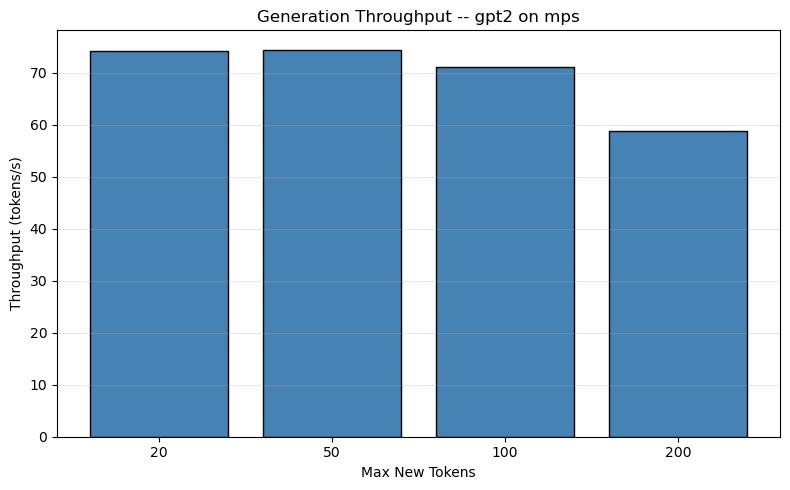

In [17]:
# Plot throughput vs generation length
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([str(g) for g in gen_lengths], throughputs, color="steelblue", edgecolor="black")
ax.set_xlabel("Max New Tokens")
ax.set_ylabel("Throughput (tokens/s)")
ax.set_title(f"Generation Throughput -- {model_name} on {device}")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---

## Part 5: Inside the Model -- Inspecting Layers and Parameters

Let's look at the internal structure of GPT-2 to connect the
architecture discussion to real code.

In [18]:
# Inspect model structure
print("Top-level modules:")
for name, module in model.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"  {name}: {params/1e6:.1f}M parameters")

print(f"\nNumber of Transformer layers: {len(model.transformer.h)}")
print(f"Hidden size (d_model): {model.config.n_embd}")
print(f"Attention heads: {model.config.n_head}")
print(f"Head dimension: {model.config.n_embd // model.config.n_head}")
print(f"Vocabulary size: {model.config.vocab_size}")
print(f"Max sequence length: {model.config.n_positions}")

Top-level modules:
  transformer: 124.4M parameters
  lm_head: 38.6M parameters

Number of Transformer layers: 12
Hidden size (d_model): 768
Attention heads: 12
Head dimension: 64
Vocabulary size: 50257
Max sequence length: 1024


In [19]:
# Look at one Transformer layer in detail
layer = model.transformer.h[0]
print("Single Transformer layer structure:")
print(layer)

print("\nParameter shapes in layer 0:")
for name, param in layer.named_parameters():
    print(f"  {name:40s}  {str(list(param.shape)):>20s}  ({param.numel():>8,} params)")

Single Transformer layer structure:
GPT2Block(
  (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (attn): GPT2Attention(
    (c_attn): Conv1D(nf=2304, nx=768)
    (c_proj): Conv1D(nf=768, nx=768)
    (attn_dropout): Dropout(p=0.1, inplace=False)
    (resid_dropout): Dropout(p=0.1, inplace=False)
  )
  (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (mlp): GPT2MLP(
    (c_fc): Conv1D(nf=3072, nx=768)
    (c_proj): Conv1D(nf=768, nx=3072)
    (act): NewGELUActivation()
    (dropout): Dropout(p=0.1, inplace=False)
  )
)

Parameter shapes in layer 0:
  ln_1.weight                                              [768]  (     768 params)
  ln_1.bias                                                [768]  (     768 params)
  attn.c_attn.weight                                 [768, 2304]  (1,769,472 params)
  attn.c_attn.bias                                        [2304]  (   2,304 params)
  attn.c_proj.weight                                  [768, 768]  ( 589,824 par

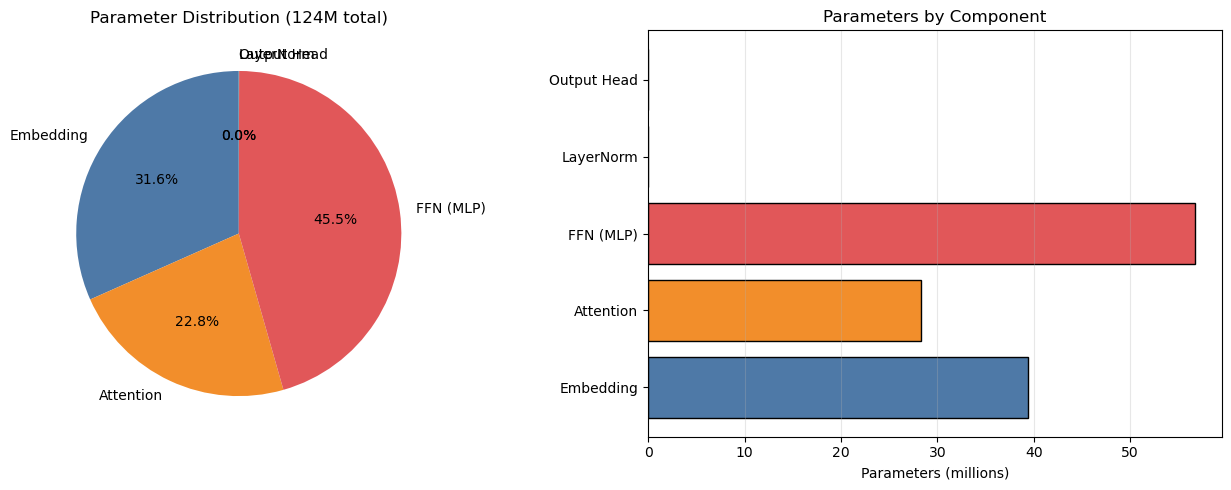


Key insight: most parameters are in the FFN (MLP) layers and attention projections.
LayerNorm adds almost no parameters -- its purpose is to stabilize training.


In [20]:
# Visualize parameter distribution across layer types
param_counts = {"Embedding": 0, "Attention": 0, "FFN (MLP)": 0, "LayerNorm": 0, "Output Head": 0}

for name, param in model.named_parameters():
    n = param.numel()
    if "wte" in name or "wpe" in name:
        param_counts["Embedding"] += n
    elif "attn" in name:
        param_counts["Attention"] += n
    elif "mlp" in name:
        param_counts["FFN (MLP)"] += n
    elif "ln" in name:
        param_counts["LayerNorm"] += n
    elif "lm_head" in name:
        param_counts["Output Head"] += n

labels = list(param_counts.keys())
sizes = [v / 1e6 for v in param_counts.values()]
colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
ax1.set_title(f"Parameter Distribution ({num_params/1e6:.0f}M total)")

ax2.barh(labels, sizes, color=colors, edgecolor="black")
ax2.set_xlabel("Parameters (millions)")
ax2.set_title("Parameters by Component")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey insight: most parameters are in the FFN (MLP) layers and attention projections.")
print("LayerNorm adds almost no parameters -- its purpose is to stabilize training.")

---

## Part 6: Prompt Engineering

Prompt engineering is how you communicate with an LLM to get useful outputs.
The same model can perform very differently depending on how you phrase your request.

### Key techniques

| Technique | Description |
| --------- | ----------- |
| **Zero-shot** | Ask directly, no examples |
| **Few-shot** | Provide examples in the prompt |
| **Chain-of-thought** | Ask the model to reason step by step |
| **System/role prompts** | Set context and constraints |

In [21]:
# Compare zero-shot vs few-shot prompting
# Task: classify the sentiment of a sentence

zero_shot = """Classify the sentiment as positive or negative.
Text: The distributed training scaled beautifully across all nodes.
Sentiment:"""

few_shot = """Classify the sentiment as positive or negative.

Text: The code compiled without errors on the first try.
Sentiment: positive

Text: The simulation crashed after wasting 10 hours of compute.
Sentiment: negative

Text: The new scheduler reduced job wait times significantly.
Sentiment: positive

Text: The distributed training scaled beautifully across all nodes.
Sentiment:"""

for label, prompt in [("Zero-shot", zero_shot), ("Few-shot", few_shot)]:
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=5, do_sample=False)
    generated = tokenizer.decode(out[0], skip_special_tokens=True)
    # Show only the completion
    answer = generated[len(prompt):].strip().split("\n")[0]
    print(f"[{label}] -> {answer}")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[Zero-shot] -> The sentiment was highly correlated
[Few-shot] -> negative


### Exercise 5: Prompt engineering practice

Using GPT-2 (or a larger model if available), try:

1. **Zero-shot**: Ask "What is MPI?" directly
2. **Few-shot**: Provide 2 examples of HPC concept definitions, then ask about MPI
3. **Chain-of-thought**: Ask "Explain step by step how MPI_Send works"
4. Try different temperatures and compare the outputs

Note: GPT-2 is small (124M params) and may produce lower-quality outputs
compared to modern LLMs. This is a great demonstration of why scale matters!

In [24]:
# YOUR CODE HERE -- experiment with prompts

my_prompt = "What is MPI?\nAnswer:"

inputs = tokenizer(my_prompt, return_tensors="pt").to(device)
with torch.no_grad():
    out = model.generate(
        **inputs,
        max_new_tokens=80,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
    )
print(tokenizer.decode(out[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


What is MPI?
Answer: MPI is the technology that enables mobile phone users to control their devices. It allows them to control their phone by using the same software that is used to control their phone. This can be done through a number of different applications, including the web browser.

MPI is a mobile phone technology that enables users to control their phone by using the same software that is used to control their phone.


---

## Part 7: Scaling and HPC Connections

### Compute requirements

Training an LLM requires enormous compute. The Chinchilla scaling law
estimates: **C = 6 * N * D** FLOPs, where N = parameters, D = training tokens.

Let's compute this for several well-known models.

In [25]:
# Compute scaling law estimates
models_info = [
    ("GPT-2",       124e6,   10e9),
    ("GPT-3",       175e9,  300e9),
    ("Llama 2 7B",    7e9,    2e12),
    ("Llama 2 70B",  70e9,    2e12),
    ("Llama 3 405B", 405e9,  15e12),
]

print(f"{'Model':<16s}  {'Params':>10s}  {'Tokens':>10s}  {'FLOPs (C=6ND)':>14s}  {'A100-hours':>12s}")
print("-" * 72)

a100_flops = 312e12  # A100 peak FP16 TFLOPS
gpu_util = 0.4       # typical MFU (model FLOP utilization)

flops_list = []
for name, N, D in models_info:
    C = 6 * N * D
    gpu_hours = C / (a100_flops * gpu_util * 3600)
    flops_list.append(C)
    
    # Format large numbers
    def fmt(x):
        if x >= 1e12: return f"{x/1e12:.0f}T"
        if x >= 1e9:  return f"{x/1e9:.0f}B"
        if x >= 1e6:  return f"{x/1e6:.0f}M"
        return f"{x:.0f}"
    
    print(f"{name:<16s}  {fmt(N):>10s}  {fmt(D):>10s}  {C:>14.2e}  {gpu_hours:>12,.0f}")

print(f"\nAssumptions: A100 peak = {a100_flops/1e12:.0f} TFLOPS (FP16), MFU = {gpu_util*100:.0f}%")

Model                 Params      Tokens   FLOPs (C=6ND)    A100-hours
------------------------------------------------------------------------
GPT-2                   124M         10B        7.44e+18            17
GPT-3                   175B        300B        3.15e+23       701,122
Llama 2 7B                7B          2T        8.40e+22       186,966
Llama 2 70B              70B          2T        8.40e+23     1,869,658
Llama 3 405B            405B         15T        3.65e+25    81,129,808

Assumptions: A100 peak = 312 TFLOPS (FP16), MFU = 40%


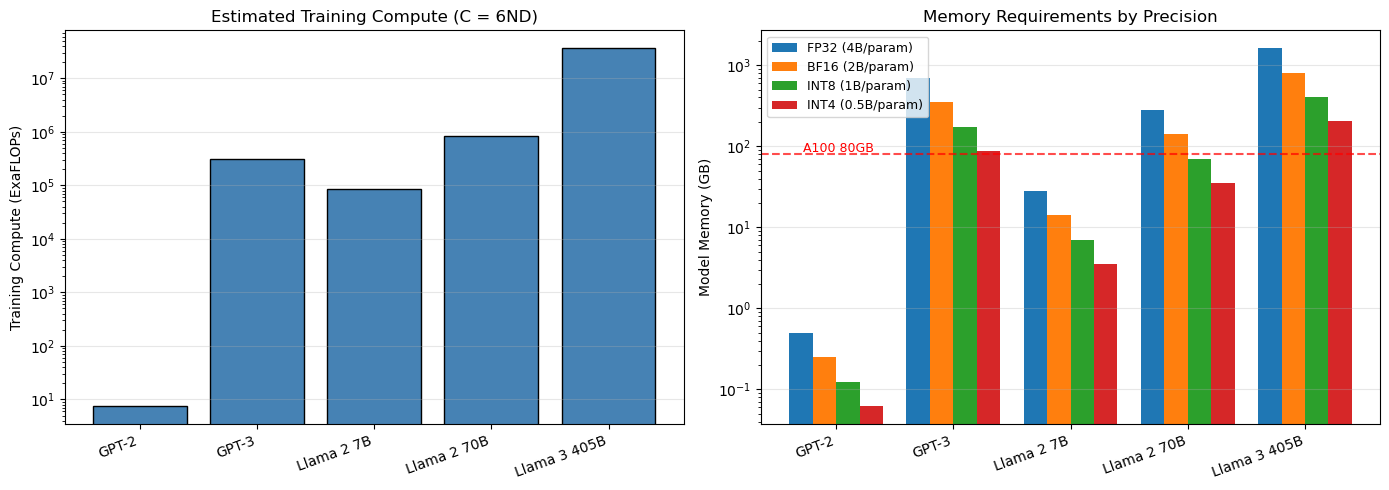

Key insight: models larger than ~40B parameters don't fit on a single A100 even in INT8.
This is why we need model parallelism across multiple GPUs -- the same HPC techniques
(tensor parallelism, pipeline parallelism, FSDP) that we studied for distributed training.


In [26]:
# Visualize the compute scaling
names = [m[0] for m in models_info]
params = [m[1] for m in models_info]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(names, [f/1e18 for f in flops_list], color="steelblue", edgecolor="black")
ax1.set_ylabel("Training Compute (ExaFLOPs)")
ax1.set_title("Estimated Training Compute (C = 6ND)")
ax1.set_yscale("log")
ax1.grid(axis="y", alpha=0.3)
plt.setp(ax1.get_xticklabels(), rotation=20, ha="right")

# Memory requirements at different precisions
precisions = {"FP32 (4B/param)": 4, "BF16 (2B/param)": 2, "INT8 (1B/param)": 1, "INT4 (0.5B/param)": 0.5}
x = np.arange(len(names))
width = 0.2

for i, (prec_name, bytes_per) in enumerate(precisions.items()):
    mem_gb = [p * bytes_per / 1e9 for p in params]
    ax2.bar(x + i * width, mem_gb, width, label=prec_name)

ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(names)
ax2.set_ylabel("Model Memory (GB)")
ax2.set_title("Memory Requirements by Precision")
ax2.set_yscale("log")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)
ax2.axhline(y=80, color="red", linestyle="--", alpha=0.7, label="A100 80GB")
ax2.text(0.02, 85, "A100 80GB", color="red", fontsize=9)
plt.setp(ax2.get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.show()

print("Key insight: models larger than ~40B parameters don't fit on a single A100 even in INT8.")
print("This is why we need model parallelism across multiple GPUs -- the same HPC techniques")
print("(tensor parallelism, pipeline parallelism, FSDP) that we studied for distributed training.")

---

## Part 8: Limitations and Responsible Use

LLMs are powerful but have important limitations:

- **Hallucination**: LLMs can generate confident but factually incorrect text.
  They are statistical pattern matchers, not knowledge databases.
- **Context window limits**: models can only process a finite number of tokens
  (e.g., 8K, 128K, or 1M tokens depending on the model).
- **Bias**: training data biases are reflected and sometimes amplified in outputs.
- **Cost**: training a frontier LLM costs tens of millions of dollars.
- **Environmental impact**: training runs consume enormous amounts of energy.

### Always verify LLM outputs, especially for:
- Scientific claims and numerical results
- Code correctness (test it!)
- Citations and references (they may be fabricated)

---

## Summary

| Concept | Key takeaway |
| ------- | ------------ |
| **Tokenization** | Text -> sub-word tokens -> integer IDs |
| **Self-Attention** | Each token attends to all others; O(n^2) in sequence length |
| **Causal masking** | Decoder-only models can only look at past tokens |
| **Autoregressive generation** | One token at a time; inherently sequential |
| **Decoding strategies** | Temperature, top-k, top-p control randomness |
| **Scaling** | C = 6ND; bigger models need HPC parallelism |
| **Prompt engineering** | How you ask matters as much as what you ask |

### Further reading

- Vaswani et al., "Attention Is All You Need" (2017)
- Brown et al., "Language Models are Few-Shot Learners" (GPT-3, 2020)
- Hoffmann et al., "Training Compute-Optimal Large Language Models" (Chinchilla, 2022)
- Touvron et al., "Llama 2" (2023)
- See `LLM.md` in the parent directory for the full reference document.